In [113]:
#import relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [114]:
#load the sales data
sales_data = pd.read_csv('Sales.csv')
sales_data.head()

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418


In [115]:
# exploring the data
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113036 entries, 0 to 113035
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Date              113036 non-null  object
 1   Day               113036 non-null  int64 
 2   Month             113036 non-null  object
 3   Year              113036 non-null  int64 
 4   Customer_Age      113036 non-null  int64 
 5   Age_Group         113036 non-null  object
 6   Customer_Gender   113036 non-null  object
 7   Country           113036 non-null  object
 8   State             113036 non-null  object
 9   Product_Category  113036 non-null  object
 10  Sub_Category      113036 non-null  object
 11  Product           113036 non-null  object
 12  Order_Quantity    113036 non-null  int64 
 13  Unit_Cost         113036 non-null  int64 
 14  Unit_Price        113036 non-null  int64 
 15  Profit            113036 non-null  int64 
 16  Cost              113036 non-null  int

In [116]:
# exploring the data
sales_data.shape

(113036, 18)

In [117]:
# checking for missing values
sales_data.isnull().sum()

Date                0
Day                 0
Month               0
Year                0
Customer_Age        0
Age_Group           0
Customer_Gender     0
Country             0
State               0
Product_Category    0
Sub_Category        0
Product             0
Order_Quantity      0
Unit_Cost           0
Unit_Price          0
Profit              0
Cost                0
Revenue             0
dtype: int64

none of the columns have missing values. Cool! 

for the time series project, I will be focusing on the ['Date'] column and the ['Order_Quantity'] column, but this dataset seems very interesting for a lot more.

In [118]:
#creating a dataframe with only the date and order quantity columns
sales_df = sales_data[['Date', 'Order_Quantity']].copy()

sales_df.head(10)

,Date,Order_Quantity
0,2013-11-26,8
1,2015-11-26,8
2,2014-03-23,23
3,2016-03-23,20
4,2014-05-15,4
5,2016-05-15,5
6,2014-05-22,4
7,2016-05-22,2
8,2014-02-22,22
9,2016-02-22,21


In [119]:
# Converting the 'Date' column to datetime object
sales_df['Date'] = pd.to_datetime(sales_df['Date'])

# Setting the 'Date' column as the index
#sales_df.set_index('Date', inplace=True)


In [120]:
# checking the new dataframe
sales_df.head()

,Date,Order_Quantity
0,2013-11-26,8
1,2015-11-26,8
2,2014-03-23,23
3,2016-03-23,20
4,2014-05-15,4


In [121]:
# still checking the new dataframe
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113036 entries, 0 to 113035
Data columns (total 2 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Date            113036 non-null  datetime64[ns]
 1   Order_Quantity  113036 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 1.7 MB


In [122]:
# Checking for missing values
sales_df.isnull().sum()

Date              0
Order_Quantity    0
dtype: int64

In [123]:
# we need to have the Date column in the order of earlier to latest but still keep the Order Quantity values in the same order with the date column. We can achieve this by sorting the sales dataframe by date in ascending order before creating the time series.
sales_df = sales_df.sort_values('Date').reset_index(drop=True)

In [124]:
sales_df.head()

,Date,Order_Quantity
0,2011-01-01,1
1,2011-01-01,2
2,2011-01-01,1
3,2011-01-01,3
4,2011-01-01,1


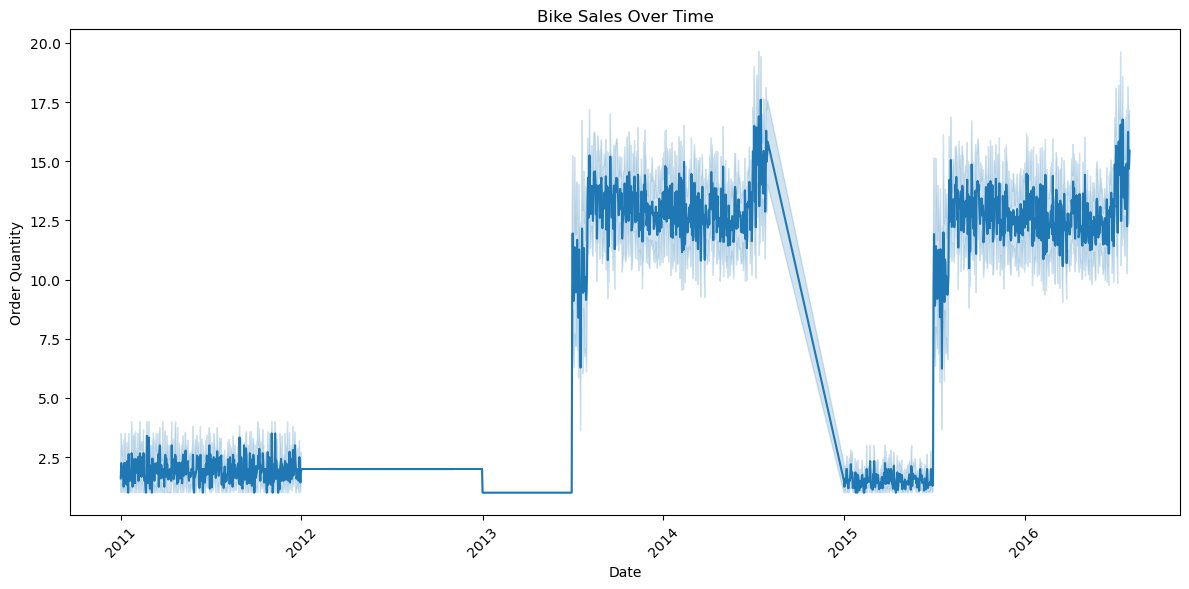

In [125]:
# plotting the time series data
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Order_Quantity', data=sales_df)
#plt.plot(sales_df['Date'], sales_df['Order_Quantity'],)
plt.title('Bike Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Order Quantity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


There doesn't seem to much of a trend until mid 2013. We should limit the data in that timeline.

In [126]:
# limiting the data to start from mid 2013
sales_df = sales_df[sales_df['Date'] >= '2013-06-01']

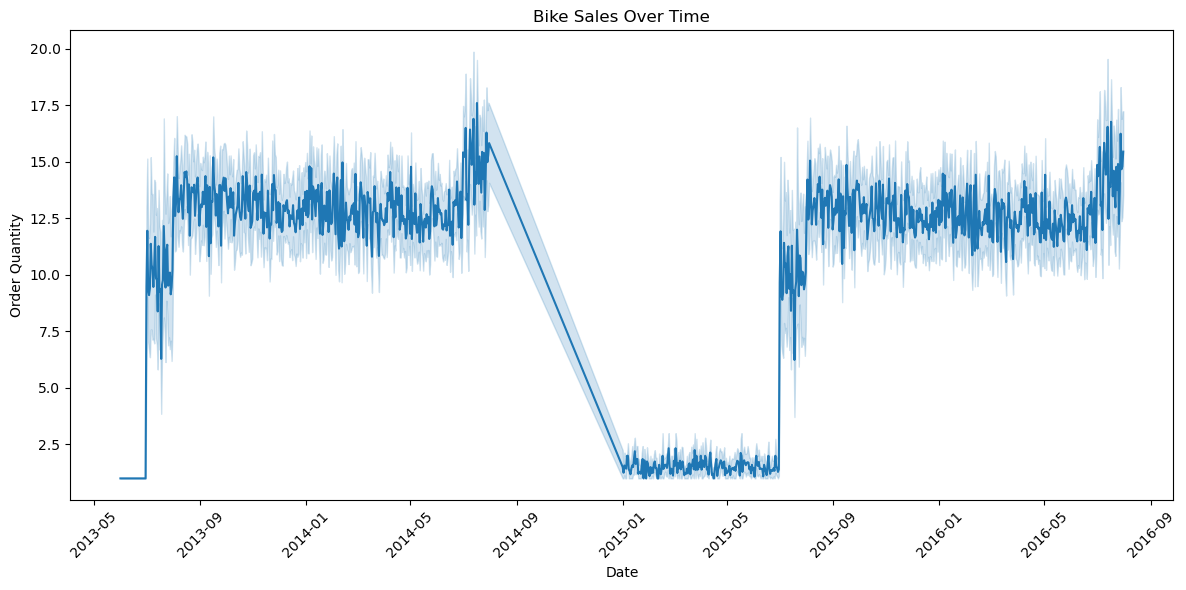

In [127]:
#plotting the time series data again
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Order_Quantity', data=sales_df)
#plt.plot(sales_df['Date'], sales_df['Order_Quantity'],)
plt.title('Bike Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Order Quantity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The trend seems to be spanning over 2 years.

In [128]:
# Preparing the data for time series forecasting


In [129]:
# transforming the data to a time series format
sales_ts = pd.Series(sales_df['Order_Quantity'].values, index=sales_df['Date'])

sales_ts.head()

Date
2013-06-01    1
2013-06-01    1
2013-06-01    1
2013-06-01    1
2013-06-01    1
dtype: int64

In [130]:
#checking the time series data
sales_ts.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 106265 entries, 2013-06-01 to 2016-07-31
Series name: None
Non-Null Count   Dtype
--------------   -----
106265 non-null  int64
dtypes: int64(1)
memory usage: 1.6 MB


In [131]:
#renaming the 0 column to 'y'
sales_ts = sales_ts.rename('y')

In [132]:
sales_ts.head()

Date
2013-06-01    1
2013-06-01    1
2013-06-01    1
2013-06-01    1
2013-06-01    1
Name: y, dtype: int64

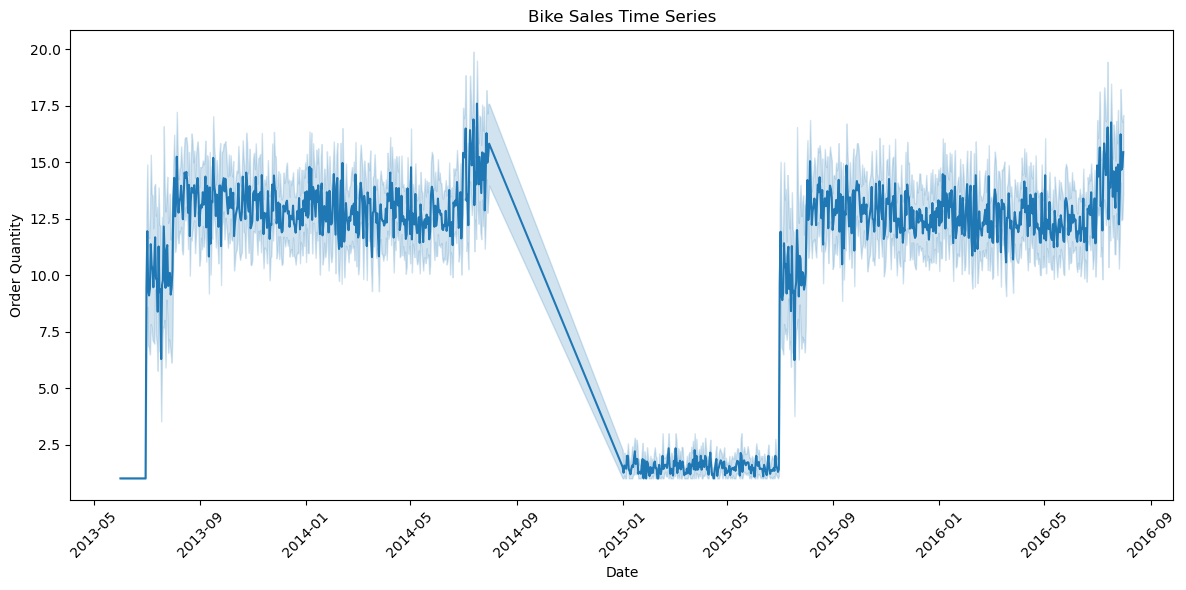

In [133]:
# Plotting sales_ts
plt.figure(figsize=(12, 6))
sns.lineplot(x=sales_ts.index, y=sales_ts.values)
plt.title('Bike Sales Time Series')
plt.xlabel('Date')
plt.ylabel('Order Quantity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [134]:
# train test split. We will use the last 6 months of data for testing and the rest for training.
train = sales_ts[sales_ts.index < '2016-01-01']
test = sales_ts[sales_ts.index >= '2016-01-01']

In [135]:
train.head(20)

Date
2013-06-01    1
2013-06-01    1
2013-06-01    1
2013-06-01    1
2013-06-01    1
2013-06-01    1
2013-06-01    1
2013-06-01    1
2013-06-01    1
2013-06-01    1
2013-06-01    1
2013-06-01    1
2013-06-01    1
2013-06-01    1
2013-06-01    1
2013-06-02    1
2013-06-02    1
2013-06-02    1
2013-06-02    1
2013-06-02    1
Name: y, dtype: int64

In [136]:
train.tail(10)

Date
2015-12-31    11
2015-12-31     3
2015-12-31     2
2015-12-31    30
2015-12-31    21
2015-12-31     4
2015-12-31    24
2015-12-31    23
2015-12-31    17
2015-12-31    27
Name: y, dtype: int64

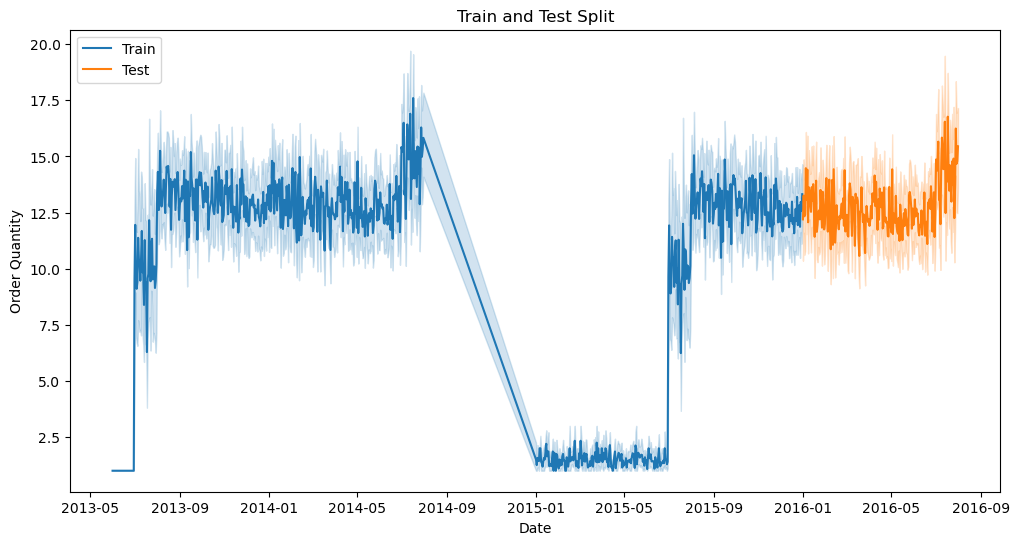

In [137]:
#plotting the train and test data
plt.figure(figsize=(12,6))
sns.lineplot(x=train.index, y=train.values, label='Train')
sns.lineplot(x=test.index, y=test.values, label='Test')
#plt.plot(train, label='Train')
#plt.plot(test, label='Test')
plt.title('Train and Test Split')
plt.xlabel('Date')
plt.ylabel('Order Quantity')
plt.legend()

I think this is a good split. Time to make a baseline ARIMA model.

In [138]:
# Let's check the shape of the train and test data
print(f'Train shape: {train.shape}')
print(f'Test shape: {test.shape}')

Train shape: (76867,)
Test shape: (29398,)


In [139]:
# Running the Dickey-Fuller test to check for stationarity
from statsmodels.tsa.stattools import adfuller

round(adfuller(train)[1], 4)

np.float64(0.0)

The data has an adfuller score of less than 0.05; therefore it is stationary. It does not need differencing.

In [140]:
# forecasting using the ARIMA model (Baseline)
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(train, order=(1, 1, 1))
model_arima_fit = model_arima.fit()
model_arima_fit.summary()

c:\Users\chept\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\chept\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\chept\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                76867
Model:                 ARIMA(1, 1, 1)   Log Likelihood             -281186.955
Date:                Fri, 22 May 2026   AIC                         562379.910
Time:                        10:02:10   BIC                         562407.660
Sample:                             0   HQIC                        562388.433
                              - 76867                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0049      0.004      1.378      0.168      -0.002       0.012
ma.L1         -0.9929      0.000  -2105.491      0.000      -0.994      -0.992
sigma2        88.0932      0.707    124.622      0.000      86.708      89.479
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              5431.15
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               0.92   Skew:                             0.26
Prob(H) (two-sided):                  0.00   Kurtosis:                         1.81
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

The Baseline ARIMA  has an AIC of 562379.91. Kind of expected since it would definitely need tuning to get the best result.



In [141]:
# Forecasting the test set using the ARIMA model
forecast_arima_result = model_arima_fit.get_forecast(steps=len(test))
mean_forecast_arima = forecast_arima_result.predicted_mean
arima_conf_int = forecast_arima_result.conf_int(alpha=0.05)

c:\Users\chept\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\chept\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


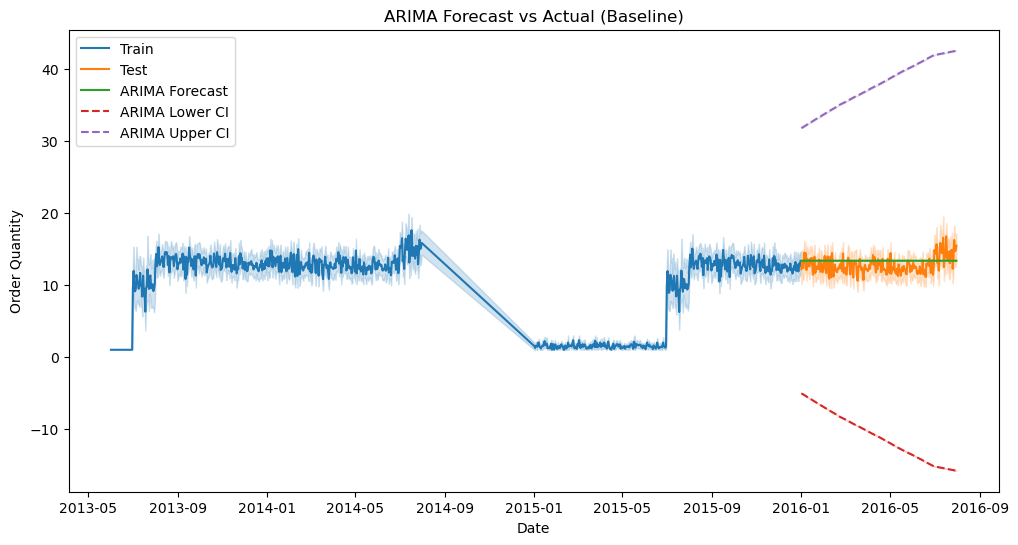

In [142]:
# plotting the forecasted values against the actual values
plt.figure(figsize=(12, 6))
sns.lineplot(x=train.index, y=train.values, label='Train')
sns.lineplot(x=test.index, y=test.values, label='Test')
sns.lineplot(x=test.index, y=mean_forecast_arima, label='ARIMA Forecast')
sns.lineplot(x=test.index, y=arima_conf_int['lower y'], label='ARIMA Lower CI', linestyle='--')
sns.lineplot(x=test.index, y=arima_conf_int['upper y'], label='ARIMA Upper CI', linestyle='--')
plt.title('ARIMA Forecast vs Actual (Baseline)')
plt.xlabel('Date')
plt.ylabel('Order Quantity')
plt.legend()


The model seems to mostly note the direction of the trend, but not following it particularly. The confidence interval is too wide. We will need to tune the hyperparameters.

In [143]:
# The Baseline ARIMA model is not performing well. We will need to tune the hyperparameters.

#p = AR 
#d = I
#q = MA
from sklearn.metrics import mean_absolute_error

best_mae = np.inf
best_order = None

output_arima_list = []
for p in range(3):
    for d in range(2):
        for q in range(3):
                model = ARIMA(train, order=(p, d, q))
                fit = model.fit()
                forecast = fit.get_forecast(steps=len(test))
                mean_forecast = forecast.predicted_mean
                mae = mean_absolute_error(test, mean_forecast)
                if mae < best_mae:
                    best_mae = mae
                    best_order = (p, d, q)
                output_arima_list.append({'order': (p, d, q),
                                      'mae': mae})

c:\Users\chept\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\chept\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\chept\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\chept\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\U

In [144]:
best_order, best_mae

((1, 0, 2), 8.201108122111863)

In [145]:
# Forecasting the test set using an ARIMA model with the best hyperparameters
model_arima_tuned = ARIMA(train, order=best_order)
model_arima_tuned_fit = model_arima_tuned.fit()
model_arima_tuned_fit.summary()

c:\Users\chept\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\chept\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\chept\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                76867
Model:                 ARIMA(1, 0, 2)   Log Likelihood             -281182.417
Date:                Fri, 22 May 2026   AIC                         562374.834
Time:                        10:08:39   BIC                         562421.083
Sample:                             0   HQIC                        562389.037
                              - 76867                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.3596      0.530     23.301      0.000      11.320      13.399
ar.L1          0.9995      0.000   4688.655      0.000       0.999       1.000
ma.L1         -0.9876      0.004   -277.861      0.000      -0.995      -0.981
ma.L2         -0.0046      0.004     -1.293      0.196      -0.012       0.002
sigma2        88.0744      0.758    116.245      0.000      86.589      89.559
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              5507.57
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.92   Skew:                             0.27
Prob(H) (two-sided):                  0.00   Kurtosis:                         1.80
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [146]:
# forecasting
forecast_arima_tuned = model_arima_tuned_fit.get_forecast(steps=len(test))
mean_forecast_arima_tuned = forecast_arima_tuned.predicted_mean
arima_tuned_conf_int = forecast_arima_tuned.conf_int(alpha=0.05)

c:\Users\chept\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\chept\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


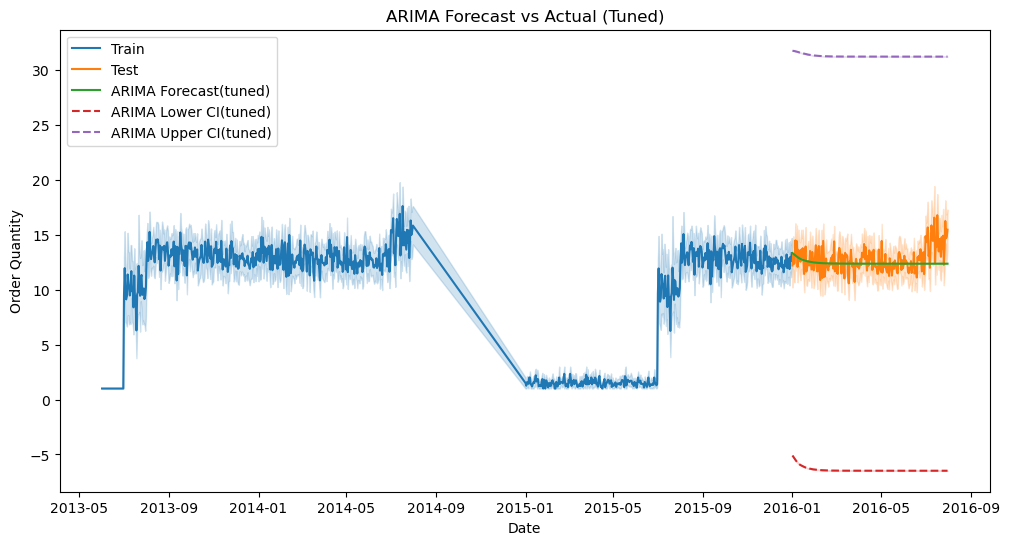

In [147]:
# plotting the forecasted tuned ARIMA values against the actual values
plt.figure(figsize=(12, 6))
sns.lineplot(x=train.index, y=train.values, label='Train')
sns.lineplot(x=test.index, y=test.values, label='Test')
sns.lineplot(x=test.index, y=mean_forecast_arima_tuned, label='ARIMA Forecast(tuned)')
sns.lineplot(x=test.index, y=arima_tuned_conf_int['lower y'], label='ARIMA Lower CI(tuned)', linestyle='--')
sns.lineplot(x=test.index, y=arima_tuned_conf_int['upper y'], label='ARIMA Upper CI(tuned)', linestyle='--')
plt.title('ARIMA Forecast vs Actual (Tuned)')
plt.xlabel('Date')
plt.ylabel('Order Quantity')
plt.legend()

In [148]:
mean_forecast_arima.info()

<class 'pandas.core.series.Series'>
RangeIndex: 29398 entries, 76867 to 106264
Series name: predicted_mean
Non-Null Count  Dtype  
--------------  -----  
29398 non-null  float64
dtypes: float64(1)
memory usage: 229.8 KB


In [149]:
# checking the accuracies of the baseline and tuned ARIMA models
mae_baseline = mean_absolute_error(test, mean_forecast_arima)
mae_tuned_arima = mean_absolute_error(test, mean_forecast_arima_tuned)

# creating a dataframe to compare the results of the baseline and tuned ARIMA models
results_df = pd.DataFrame({
    'Model': ['Baseline ARIMA', 'Tuned ARIMA'],
    'MAE': [mae_baseline, mae_tuned_arima]
})

results_df

,Model,MAE
0,Baseline ARIMA,8.265485
1,Tuned ARIMA,8.201108


We can see that the tuned ARIMA model has a lower MAE than the baseline ARIMA model, indicating that it is performing better in forecasting the bike sales.

We should tune the ARIMA model further by changing the step value to forecast one day at a time.

In [150]:
# Forecasting the ARIMA model one day at a time.
# Make a train data list
'''
train_list = list(train)
arima_forecast_one_day = []

# for loop to forecast one day at a time
for i in range(len(test)):
    model_arima_one_day = ARIMA(train_list, order=best_order)
    model_arima_one_day_fit = model_arima_one_day.fit()
    forecast_one_day = model_arima_one_day_fit.get_forecast(steps=1)
    arima_forecast_one_day.append(forecast_one_day[0])
    # Append the forecasted value to the train list for the next iteration
    train_list.append(forecast_one_day[0])
'''
# the above code is taking too long to run. We will need to optimize it. We will use get_forecast.

'\ntrain_list = list(train)\narima_forecast_one_day = []\n\n# for loop to forecast one day at a time\nfor i in range(len(test)):\n    model_arima_one_day = ARIMA(train_list, order=best_order)\n    model_arima_one_day_fit = model_arima_one_day.fit()\n    forecast_one_day = model_arima_one_day_fit.get_forecast(steps=1)\n    arima_forecast_one_day.append(forecast_one_day[0])\n    # Append the forecasted value to the train list for the next iteration\n    train_list.append(forecast_one_day[0])\n'

In [151]:
# creating confidence intervals for the one day at a time forecast
#arima_one_day_conf_int =forecast_one_day.conf_int(alpha=0.05)

In [152]:
# plotting the ARIMA one-day-at-a-time forecast against the actual values
'''
plt.figure(figsize=(12, 6))
sns.lineplot(x=train.index, y=train.values, label='Train')
sns.lineplot(x=test.index, y=test.values, label='Test')
sns.lineplot(x=test.index, y=arima_forecast_one_day, label='ARIMA Forecast(one day at a time)')
sns.lineplot(x=test.index, y=arima_one_day_conf_int['lower y'], label='ARIMA Lower CI(One Day at a Time)', linestyle='--')
sns.lineplot(x=test.index, y=arima_one_day_conf_int['upper y'], label='ARIMA Upper CI(One Day at a Time)', linestyle='--')
plt.title('ARIMA Forecast vs Actual (One day at a time)')
plt.xlabel('Date')
plt.ylabel('Order Quantity')
plt.legend()
'''

"\nplt.figure(figsize=(12, 6))\nsns.lineplot(x=train.index, y=train.values, label='Train')\nsns.lineplot(x=test.index, y=test.values, label='Test')\nsns.lineplot(x=test.index, y=arima_forecast_one_day, label='ARIMA Forecast(one day at a time)')\nsns.lineplot(x=test.index, y=arima_one_day_conf_int['lower y'], label='ARIMA Lower CI(One Day at a Time)', linestyle='--')\nsns.lineplot(x=test.index, y=arima_one_day_conf_int['upper y'], label='ARIMA Upper CI(One Day at a Time)', linestyle='--')\nplt.title('ARIMA Forecast vs Actual (One day at a time)')\nplt.xlabel('Date')\nplt.ylabel('Order Quantity')\nplt.legend()\n"

We will now try out forecasting using the Facebook Prophet model.

In [153]:
# Downloading the Facebook Prophet library
import sys
!{sys.executable} -m pip install prophet

In [154]:
# Forecasting using the Facebook Prophet model
from prophet import Prophet
#preparing the data for Prophet
# Prophet requires the data to be in a specific format with columns 'ds' for date and 'y' for the target variable
# converting the train data to the format required by Prophet
df_prophet = train.reset_index()

#renaming the columns to 'ds' and 'y'
df_prophet.columns = ['ds', 'y']

In [155]:
df_prophet.head()

,ds,y
0,2013-06-01,1
1,2013-06-01,1
2,2013-06-01,1
3,2013-06-01,1
4,2013-06-01,1


In [156]:
# Fitting the Prophet model
model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model_prophet.fit(df_prophet)


10:09:31 - cmdstanpy - INFO - Chain [1] start processing
10:10:02 - cmdstanpy - INFO - Chain [1] done processing


([<matplotlib.axis.XTick at 0x195c548b9d0>,
 [Text(0, 0, 'Jan'),
  Text(1, 0, 'Feb'),
  Text(2, 0, 'Mar'),
  Text(3, 0, 'Apr'),
  Text(4, 0, 'May'),
  Text(5, 0, 'Jun'),
  Text(6, 0, 'Jul'),
  Text(7, 0, 'Aug'),
  Text(8, 0, 'Sep'),
  Text(9, 0, 'Oct'),
  Text(10, 0, 'Nov'),
  Text(11, 0, 'Dec')])

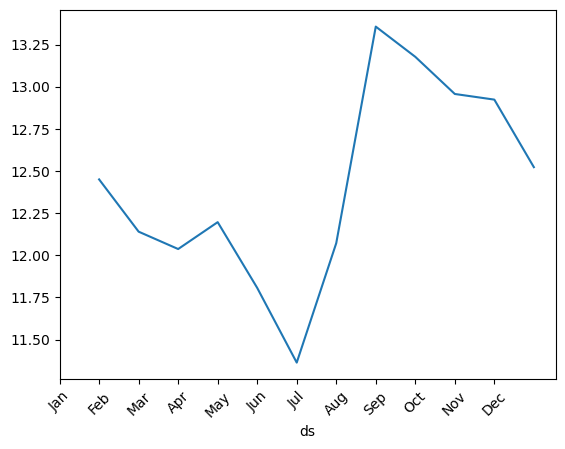

In [157]:
# Plotting the mean y values for each month to visualize the seasonality
df_prophet.groupby(df_prophet['ds'].dt.month)['y'].mean().plot(kind='line')
plt.xticks(rotation=45)
plt.xticks(ticks=range(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

There does seem to be some kind of dip and rise from the first half of the year to the second half, with the highest peek on August. Definitely suggest a monthly seasonality.

(array([2012.75, 2013.  , 2013.25, 2013.5 , 2013.75, 2014.  , 2014.25,
        2014.5 , 2014.75, 2015.  , 2015.25]),
 [Text(2012.75, 0, '2012.75'),
  Text(2013.0, 0, '2013.00'),
  Text(2013.25, 0, '2013.25'),
  Text(2013.5, 0, '2013.50'),
  Text(2013.75, 0, '2013.75'),
  Text(2014.0, 0, '2014.00'),
  Text(2014.25, 0, '2014.25'),
  Text(2014.5, 0, '2014.50'),
  Text(2014.75, 0, '2014.75'),
  Text(2015.0, 0, '2015.00'),
  Text(2015.25, 0, '2015.25')])

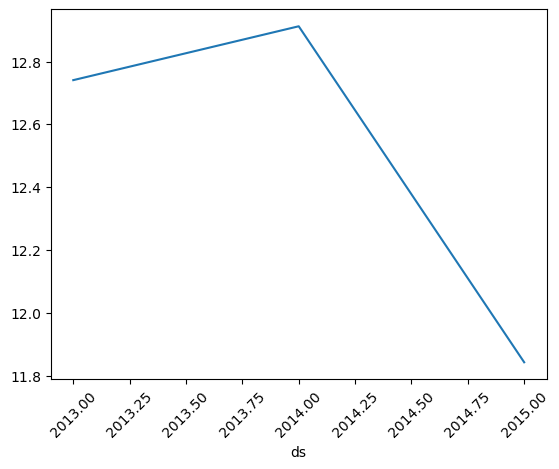

In [158]:
# Plotting out the mean y values for each year to visualise the trend
df_prophet.groupby(df_prophet['ds'].dt.year)['y'].mean().plot(kind='line')
plt.xticks(rotation=45)
#plt.xticks(ticks=range(2013, 2017), labels=['2013', '2014', '2015', '2016'])

The yearly trend suggests a rise from 2013 and 2014, and then a fall between 2014 and 2015.

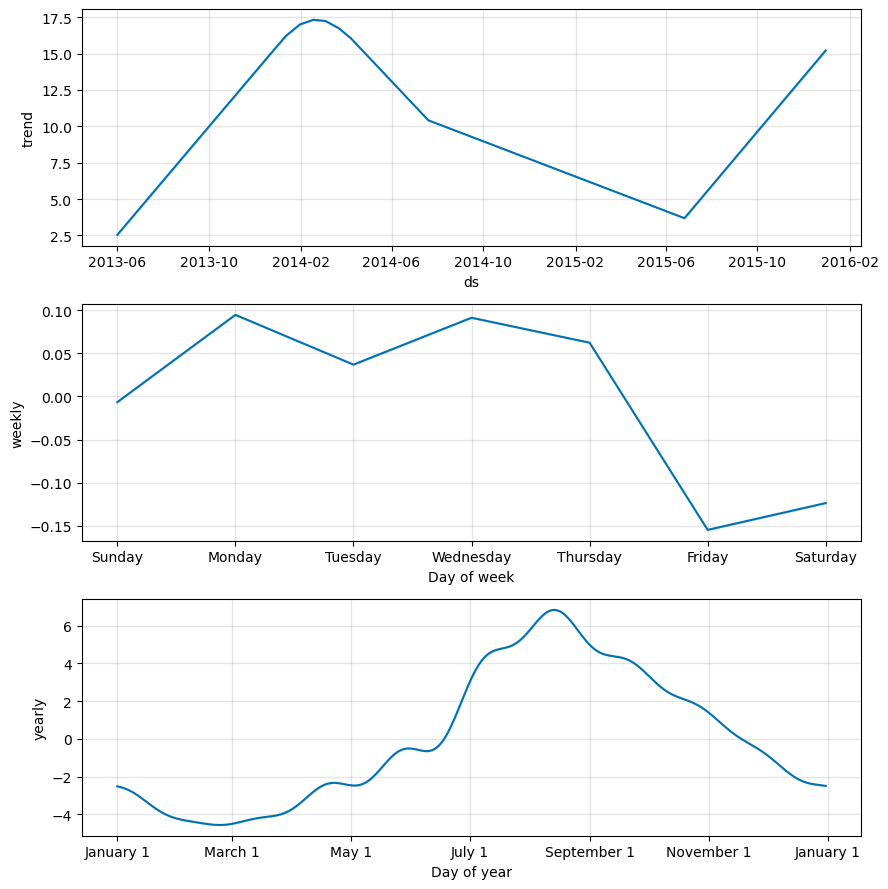

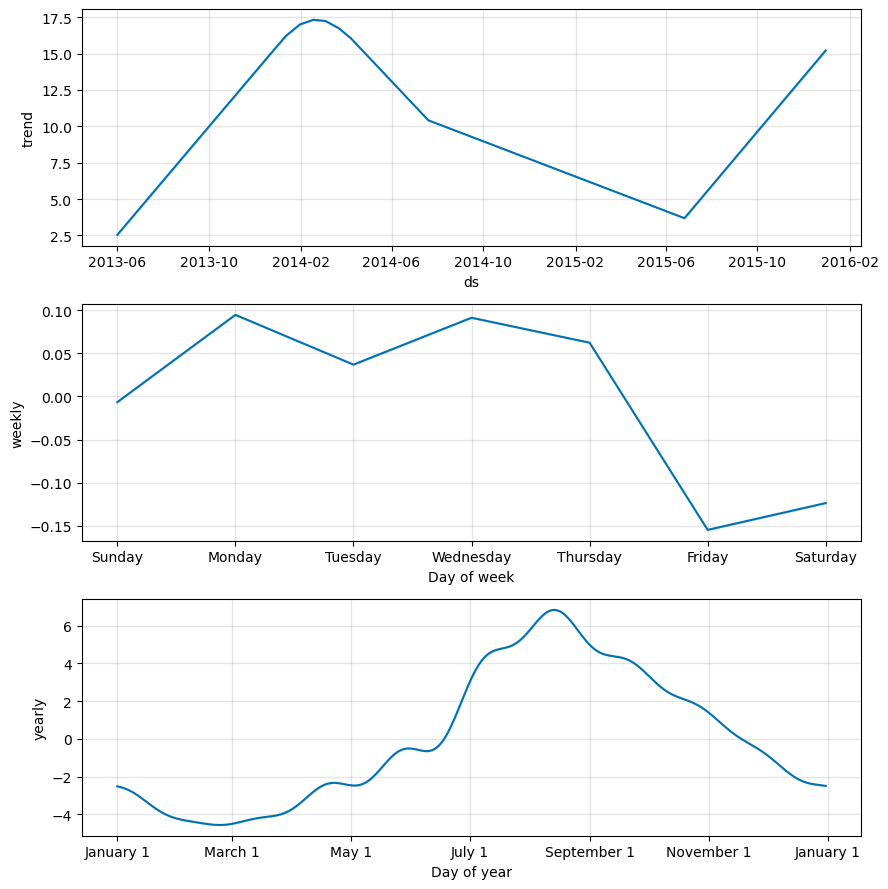

In [159]:
# Displaying the components of the Prophet model to understand the trend and seasonality
model_prophet.plot_components(model_prophet.predict(df_prophet))

From these visualizations, we can see that the yearly trend shows a rise, a fall, and another rise beginning in 2015. If the trend stays true, we expect the sales to peek in 2016 and then fall again towards 2017.

we can also see a rising and falling trend in the monthly sales, with the peek at August, when most sales are made. The lowest sales are in February.

There does also seem to be a weekly trend, with most of the positive trend happening in most weekdays except Friday, and a negative trend in the weekend.

In [160]:
# Forecasting the test set using the Prophet model
future = model_prophet.make_future_dataframe(periods=len(test), freq='D')
forecast_prophet = model_prophet.predict(future)

forecast_prophet.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2013-06-01,2.540261,-10.805928,14.452909,2.540261,2.540261,-0.637211,-0.637211,-0.637211,-0.123651,-0.123651,-0.123651,-0.513560,-0.513560,-0.513560,0.0,0.0,0.0,1.903050
1,2013-06-02,2.601300,-9.229008,14.985300,2.601300,2.601300,-0.533989,-0.533989,-0.533989,-0.006593,-0.006593,-0.006593,-0.527396,-0.527396,-0.527396,0.0,0.0,0.0,2.067311
2,2013-06-03,2.662339,-9.632808,14.696063,2.662339,2.662339,-0.452267,-0.452267,-0.452267,0.094576,0.094576,0.094576,-0.546843,-0.546843,-0.546843,0.0,0.0,0.0,2.210071
3,2013-06-04,2.723377,-9.397213,14.218857,2.723377,2.723377,-0.532905,-0.532905,-0.532905,0.036877,0.036877,0.036877,-0.569783,-0.569783,-0.569783,0.0,0.0,0.0,2.190472
4,2013-06-05,2.784416,-10.282039,13.844892,2.784416,2.784416,-0.502677,-0.502677,-0.502677,0.091231,0.091231,0.091231,-0.593908,-0.593908,-0.593908,0.0,0.0,0.0,2.281740


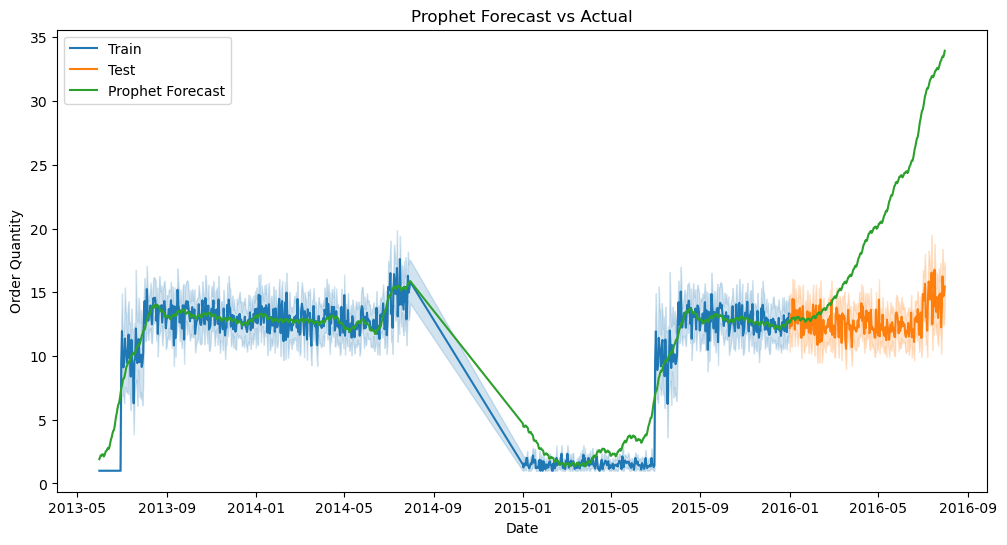

In [161]:
# Plotting the original data and the forecasted values from the Prophet model

mask = forecast_prophet['ds'] <= test.index.max()
plt.figure(figsize=(12, 6))
sns.lineplot(x=train.index, y=train.values, label='Train')
sns.lineplot(x=test.index, y=test.values, label='Test')
sns.lineplot(x=forecast_prophet.loc[mask, 'ds'], y=forecast_prophet.loc[mask, 'yhat'], label='Prophet Forecast')
#sns.lineplot(x=forecast_prophet['ds'], y=forecast_prophet['yhat'], label='Prophet Forecast')
plt.title('Prophet Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Order Quantity')
#plt.xlim(train.index.min(), test.index.max())
#plt.show()
plt.legend()

The Prophet model seems to perform rather poorly in this dataset. We will need to look at its Mean Absolute Error score and compare it with the other models.

We should also try out a Prophet model with auto seasonality parameters, and a one day at a time model.

In [162]:
# Checking the accuracy of the Prophet model
# We will use the mean absolute error (MAE) to compare the performance with the ARIMA models

prophet_pred = forecast_prophet.set_index('ds').reindex(test.index)['yhat']
mae_prophet = mean_absolute_error(test, prophet_pred)
mae_prophet

10.765112606750458

In [163]:
# Comparing the Prophet model performance with the ARIMA models
results_df = pd.DataFrame({
    'Model': ['Prophet', 'ARIMA Baseline', 'ARIMA Tuned'],
    'MAE': [mae_prophet, mae_baseline, mae_tuned_arima]
}) 

results_df

,Model,MAE
0,Prophet,10.765113
1,ARIMA Baseline,8.265485
2,ARIMA Tuned,8.201108


The Prophet model has performed worse than the ARIMA models this time. We should tune the Prophet model to forecast on auto.

In [164]:
# Making  an instance of the Prophet model with hyperparameters set to auto to see if we can improve the performance
model_prophet_auto = Prophet(yearly_seasonality='auto', 
                            weekly_seasonality='auto', 
                            daily_seasonality='auto')

# Fitting the Prophet model with auto hyperparameters
model_prophet_auto.fit(df_prophet)

10:10:52 - cmdstanpy - INFO - Chain [1] start processing
10:11:20 - cmdstanpy - INFO - Chain [1] done processing


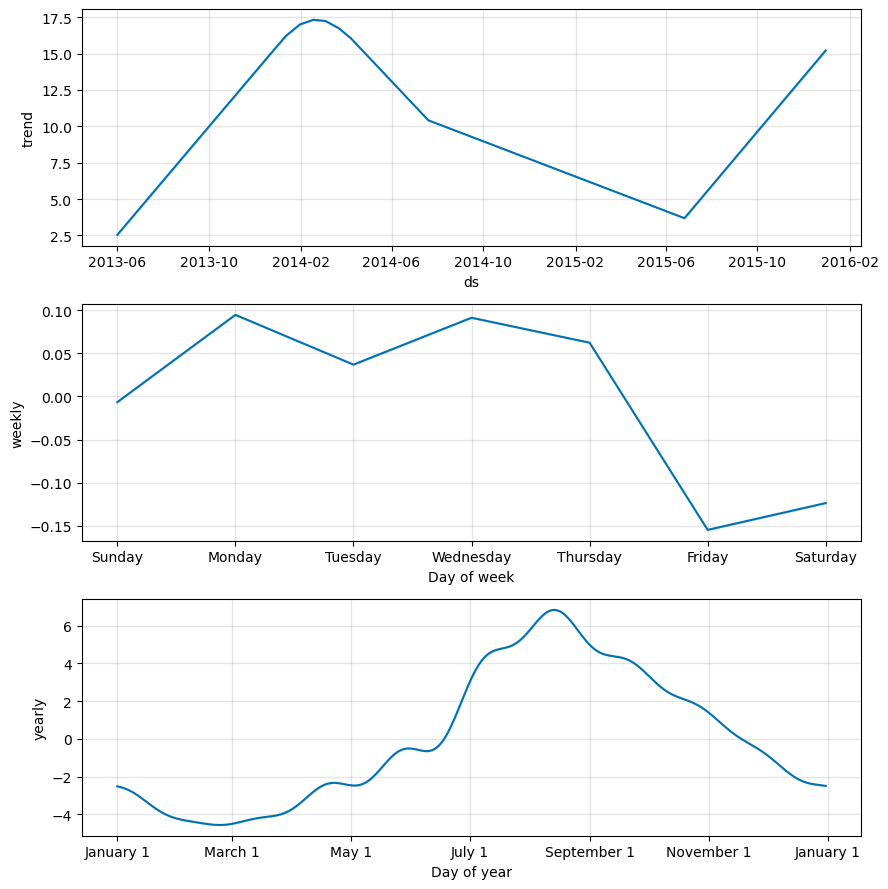

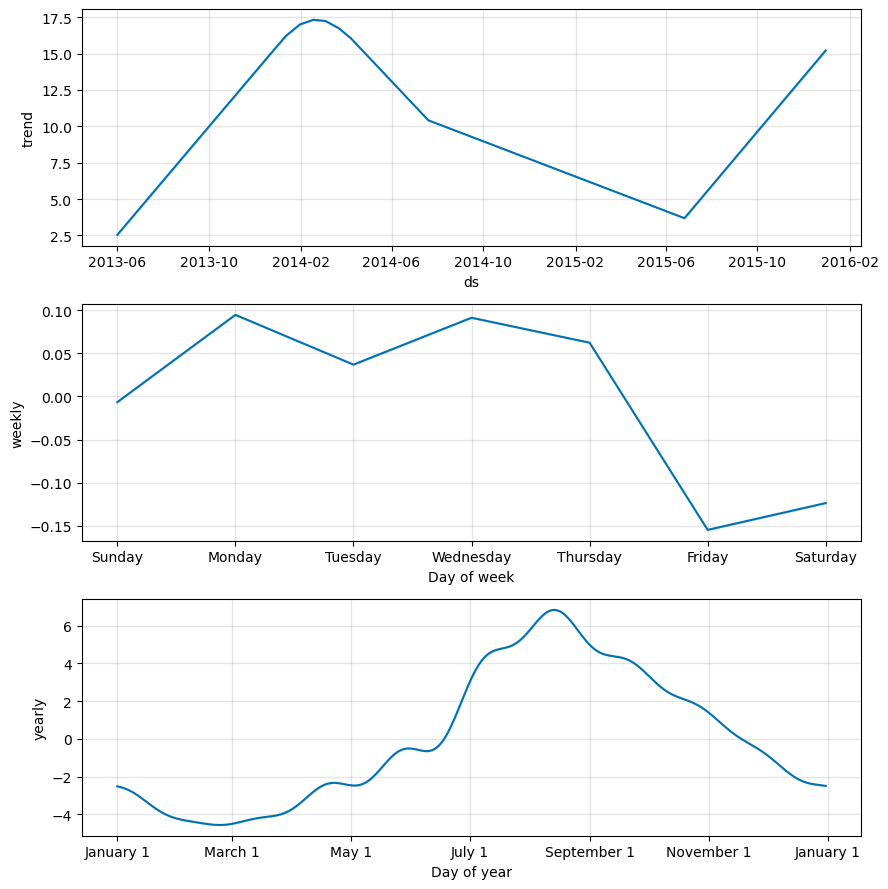

In [165]:
# Displaying the components of the Prophet auto model to understand the trend and seasonality
model_prophet_auto.plot_components(model_prophet_auto.predict(df_prophet))

In [166]:
# Forecasting the test set using the Prophet auto model
future_auto = model_prophet_auto.make_future_dataframe(periods=len(test), freq='D')
forecast_prophet_auto = model_prophet_auto.predict(future_auto)

forecast_prophet_auto.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2013-06-01,2.540261,-9.967848,14.449997,2.540261,2.540261,-0.637211,-0.637211,-0.637211,-0.123651,-0.123651,-0.123651,-0.513560,-0.513560,-0.513560,0.0,0.0,0.0,1.903050
1,2013-06-02,2.601300,-10.422299,13.587364,2.601300,2.601300,-0.533989,-0.533989,-0.533989,-0.006593,-0.006593,-0.006593,-0.527396,-0.527396,-0.527396,0.0,0.0,0.0,2.067311
2,2013-06-03,2.662339,-9.573713,14.083243,2.662339,2.662339,-0.452267,-0.452267,-0.452267,0.094576,0.094576,0.094576,-0.546843,-0.546843,-0.546843,0.0,0.0,0.0,2.210071
3,2013-06-04,2.723377,-10.379667,14.261318,2.723377,2.723377,-0.532905,-0.532905,-0.532905,0.036877,0.036877,0.036877,-0.569783,-0.569783,-0.569783,0.0,0.0,0.0,2.190472
4,2013-06-05,2.784416,-10.170477,14.223577,2.784416,2.784416,-0.502677,-0.502677,-0.502677,0.091231,0.091231,0.091231,-0.593908,-0.593908,-0.593908,0.0,0.0,0.0,2.281740


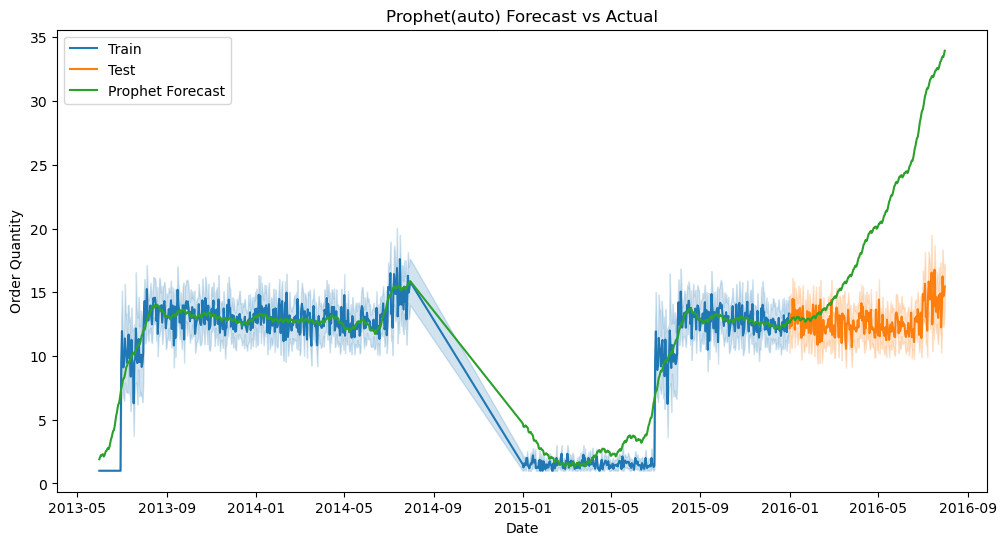

In [167]:
# Plotting the original data and the forecasted values from the Prophet auto model

mask_auto = forecast_prophet_auto['ds'] <= test.index.max()
plt.figure(figsize=(12, 6))
sns.lineplot(x=train.index, y=train.values, label='Train')
sns.lineplot(x=test.index, y=test.values, label='Test')
sns.lineplot(x=forecast_prophet_auto.loc[mask_auto, 'ds'], y=forecast_prophet_auto.loc[mask_auto, 'yhat'], label='Prophet Forecast')
#sns.lineplot(x=forecast_prophet_auto['ds'], y=forecast_prophet_auto['yhat'], label='Prophet Forecast')
plt.title('Prophet(auto) Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Order Quantity')
#plt.xlim(train.index.min(), test.index.max())
#plt.show()
plt.legend()

The Prophet auto model seems to perform just like the first Prophet model

In [168]:
# Checking the accuracy of the Prophet auto model
# We will use the mean absolute error (MAE) to compare the performance with the ARIMA models

prophet_auto_pred = forecast_prophet_auto.set_index('ds').reindex(test.index)['yhat']
mae_prophet_auto = mean_absolute_error(test, prophet_auto_pred)
mae_prophet_auto

10.765112606750458

In [169]:
# Comparing the Prophet(auto) model performance with the ARIMA models
results_df = pd.DataFrame({
    'Model': ['Prophet(auto)', 'Prophet', 'ARIMA Baseline', 'ARIMA Tuned'],
    'MAE': [mae_prophet_auto, mae_prophet, mae_baseline, mae_tuned_arima]
}) 

results_df

,Model,MAE
0,Prophet(auto),10.765113
1,Prophet,10.765113
2,ARIMA Baseline,8.265485
3,ARIMA Tuned,8.201108


In [170]:
# Trying out a Prophet model forecasting one day at a time to see if we can improve the performance.

# This will take a long time to run.
print("This will take a long time to run. Please be patient...")

'''
forecast_prophet_one_day = []
prophet_train = df_prophet.copy()

for i in range(len(test)):
    # creating a new Prophet model for each iteration to one day at a time forecast
    model_prophet_one_day = Prophet(yearly_seasonality='auto', 
                                   weekly_seasonality='auto', 
                                   daily_seasonality='auto')
    # fitting the model on the current train data
    model_prophet_one_day.fit(prophet_train)
    # forecasting one day ahead
    future_one_day = model_prophet_one_day.make_future_dataframe(periods=1, freq='D')
    forecast_one_day = model_prophet_one_day.predict(future_one_day)
    # appending the forecasted value to the list
    forecast_prophet_one_day.append(forecast_one_day['yhat'].iloc[-1])
    # Appending the forecasted value to the train data for the next iteration
    new_row = pd.DataFrame({'ds': future_one_day['ds'].iloc[-1], 
                            'y': forecast_one_day['yhat'].iloc[-1]}, index=[0])
    prophet_train = pd.concat([prophet_train, new_row], ignore_index=True)

forecast_prophet_one_day
'''

This will take a long time to run. Please be patient...


"\nforecast_prophet_one_day = []\nprophet_train = df_prophet.copy()\n\nfor i in range(len(test)):\n    # creating a new Prophet model for each iteration to one day at a time forecast\n    model_prophet_one_day = Prophet(yearly_seasonality='auto', \n                                   weekly_seasonality='auto', \n                                   daily_seasonality='auto')\n    # fitting the model on the current train data\n    model_prophet_one_day.fit(prophet_train)\n    # forecasting one day ahead\n    future_one_day = model_prophet_one_day.make_future_dataframe(periods=1, freq='D')\n    forecast_one_day = model_prophet_one_day.predict(future_one_day)\n    # appending the forecasted value to the list\n    forecast_prophet_one_day.append(forecast_one_day['yhat'].iloc[-1])\n    # Appending the forecasted value to the train data for the next iteration\n    new_row = pd.DataFrame({'ds': future_one_day['ds'].iloc[-1], \n                            'y': forecast_one_day['yhat'].iloc[-1]}, i

The one day at a time models are taking a very long time. Well over 12 hours.

We will be trying out a Time Series using Machine Learning models. 

In [171]:
# Forecasting using Machine Learning models like Linear Regression, Random Forest and XGBoost.
# we will use the sales_ts data for this.
# we will need to create lag features to captures the temporal dependencies in the data.
# we will also create rolling mean features to capture the trend in the data.

sales_ts.head()

Date
2013-06-01    1
2013-06-01    1
2013-06-01    1
2013-06-01    1
2013-06-01    1
Name: y, dtype: int64

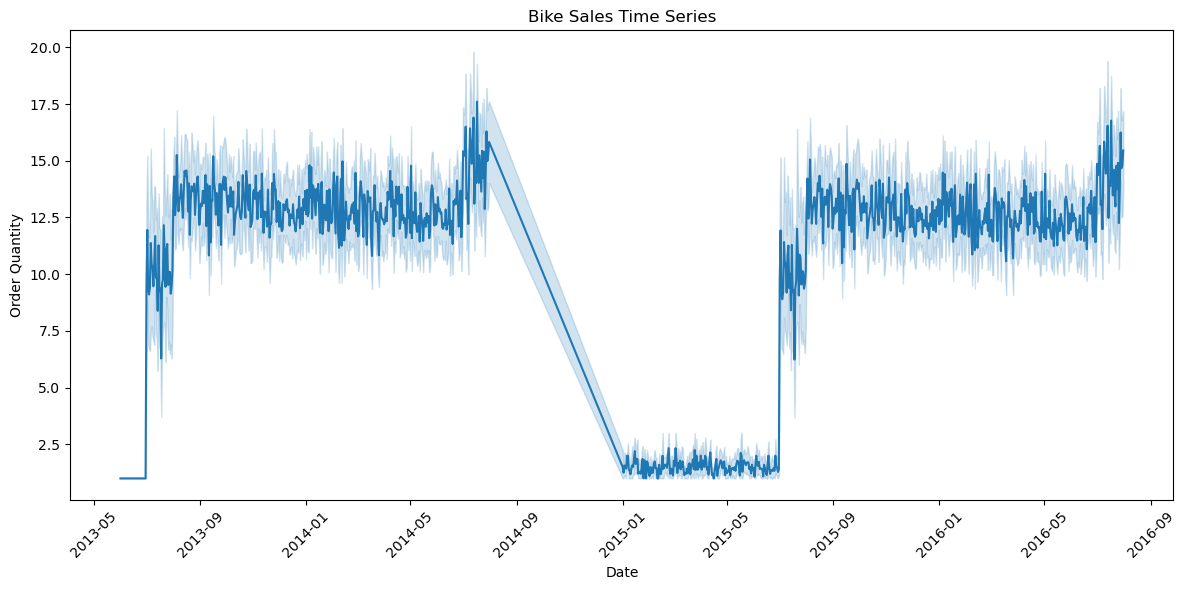

In [172]:
# Plotting the data.
plt.figure(figsize=(12, 6))
sns.lineplot(x=sales_ts.index, y=sales_ts.values)
plt.title('Bike Sales Time Series')
plt.xlabel('Date')
plt.ylabel('Order Quantity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Creating Lag features

In [173]:
# Checking the type of data in sales_ts
type(sales_ts)

pandas.core.series.Series

In [174]:
# changing the sales_ts datatype to a dataframe to create lag features and rolling mean features.
sales_ts_df = sales_ts.to_frame().reset_index()
sales_ts_df.head()

,Date,y
0,2013-06-01,1
1,2013-06-01,1
2,2013-06-01,1
3,2013-06-01,1
4,2013-06-01,1


In [175]:
# Checking the datatype of sales_ts_df
type(sales_ts_df)

pandas.core.frame.DataFrame

In [176]:
# Adding lag features to the sales_ts_df dataframe
for lag in [7, 14, 21, 30]:
    sales_ts_df[f'lag_{lag}'] = sales_ts_df['y'].shift(lag)

sales_ts_df.head()

,Date,y,lag_7,lag_14,lag_21,lag_30
0,2013-06-01,1,NaN,NaN,NaN,NaN
1,2013-06-01,1,NaN,NaN,NaN,NaN
2,2013-06-01,1,NaN,NaN,NaN,NaN
3,2013-06-01,1,NaN,NaN,NaN,NaN
4,2013-06-01,1,NaN,NaN,NaN,NaN


In [177]:
# Checking the sales_ts_df sample with the lag features
sales_ts_df.sample(5)

,Date,y,lag_7,lag_14,lag_21,lag_30
52291,2014-07-30,4,17.0,25.0,1.0,22.0
17392,2013-11-28,22,23.0,4.0,25.0,6.0
20525,2013-12-16,28,1.0,10.0,22.0,7.0
76318,2015-12-28,8,28.0,15.0,1.0,24.0
95662,2016-05-09,26,11.0,26.0,2.0,2.0


In [178]:
# Checking the correlation between the target variable 'y' and the lag features
sales_ts_df.corr()['y']

# These are the ML analog of AR terms

Date     -0.010795
y         1.000000
lag_7     0.030882
lag_14    0.031556
lag_21    0.027485
lag_30    0.034713
Name: y, dtype: float64

the correlation seems to be going higher. This is not what was expected. Curious what is happenning here.

In [179]:
# Creating the rolling mean features
for window in [7, 14, 21, 30]:
    sales_ts_df[f'rolling_mean_{window}'] = sales_ts_df['y'].rolling(window=window).mean()

sales_ts_df.sample(5)

,Date,y,lag_7,lag_14,lag_21,lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_21,rolling_mean_30
87612,2016-03-18,4,17.0,18.0,3.0,15.0,6.142857,9.571429,9.000000,9.533333
54881,2015-07-16,16,5.0,5.0,10.0,10.0,13.428571,8.500000,8.571429,8.333333
90761,2016-04-09,19,12.0,4.0,16.0,20.0,18.142857,15.285714,14.476190,14.333333
27716,2014-02-04,18,22.0,7.0,5.0,25.0,11.285714,14.357143,15.523810,14.100000
50286,2014-06-30,13,14.0,7.0,1.0,1.0,9.142857,11.000000,11.285714,12.000000


In [180]:
# Adding rolling standard deviation features to capture the volatility in the data
for window2 in [7, 14, 21, 30]:
    sales_ts_df[f'rolling_std_{window2}'] = sales_ts_df['y'].rolling(window=window2).std()

sales_ts_df.sample(5)

,Date,y,lag_7,lag_14,lag_21,lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_21,rolling_mean_30,rolling_std_7,rolling_std_14,rolling_std_21,rolling_std_30
65829,2015-10-19,11,24.0,23.0,1.0,1.0,14.285714,13.428571,11.761905,12.100000,11.513967,10.112553,9.868661,10.080196
100151,2016-06-07,18,3.0,17.0,26.0,1.0,11.142857,11.285714,13.523810,12.900000,10.090071,10.483897,10.633057,10.090453
65200,2015-10-14,6,4.0,1.0,7.0,16.0,15.714286,13.500000,13.142857,12.966667,9.860938,9.803845,9.645132,9.665022
38858,2014-04-22,26,8.0,5.0,24.0,1.0,17.428571,16.214286,12.190476,13.100000,9.744351,9.241866,9.765342,10.749018
7921,2013-09-19,10,12.0,24.0,1.0,13.0,11.285714,11.357143,10.380952,10.533333,10.403754,9.303491,9.140439,8.708828


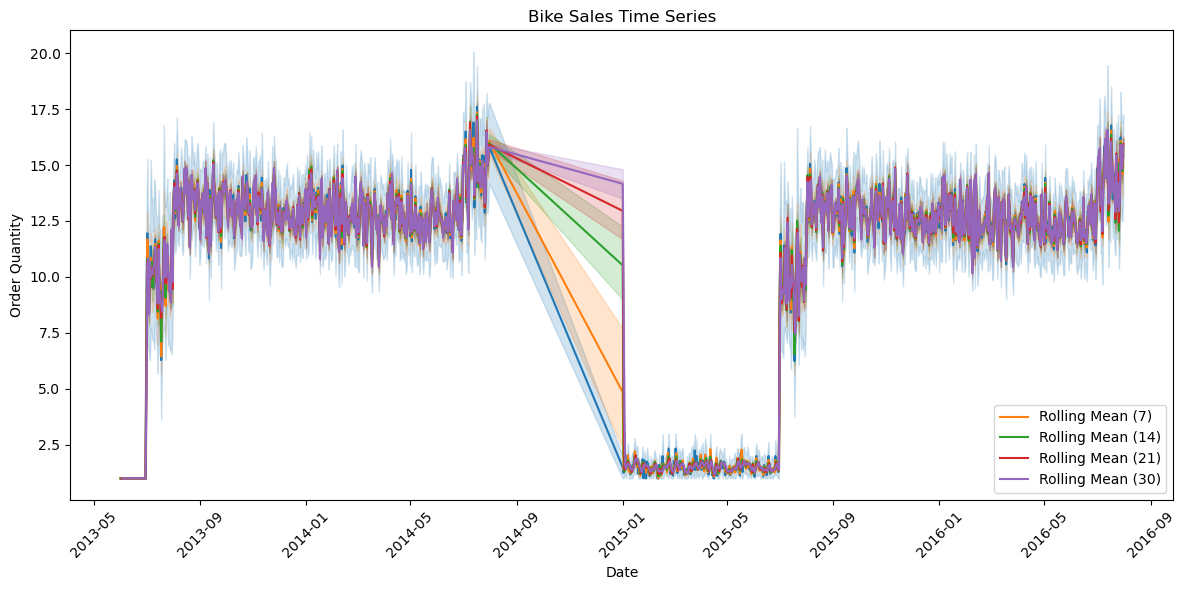

In [181]:
# Plotting the original time series data and the rolling mean features.
plt.figure(figsize=(12, 6))
sns.lineplot(x=sales_ts.index, y=sales_ts.values)
sns.lineplot(x=sales_ts_df['Date'], y=sales_ts_df['rolling_mean_7'], label='Rolling Mean (7)')
sns.lineplot(x=sales_ts_df['Date'], y=sales_ts_df['rolling_mean_14'], label='Rolling Mean (14)')
sns.lineplot(x=sales_ts_df['Date'], y=sales_ts_df['rolling_mean_21'], label='Rolling Mean (21)')
sns.lineplot(x=sales_ts_df['Date'], y=sales_ts_df['rolling_mean_30'], label='Rolling Mean (30)')
plt.title('Bike Sales Time Series')
plt.xlabel('Date')
plt.ylabel('Order Quantity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

In [182]:
# grabbing day, month and year from the 'Date' column to capture any seasonality
sales_ts_df['day'] = sales_ts_df['Date'].dt.day
sales_ts_df['month'] = sales_ts_df['Date'].dt.month
sales_ts_df['year'] = sales_ts_df['Date'].dt.year

sales_ts_df.sample(5)

,Date,y,lag_7,lag_14,lag_21,lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_21,rolling_mean_30,rolling_std_7,rolling_std_14,rolling_std_21,rolling_std_30,day,month,year
66846,2015-10-27,24,7.0,12.0,1.0,12.0,14.857143,15.500000,14.476190,13.700000,8.375133,10.150786,9.744840,9.173237,27,10,2015
48587,2014-06-20,10,24.0,16.0,14.0,1.0,12.428571,13.714286,13.857143,14.266667,7.457818,9.268877,8.696469,8.916986,20,6,2014
86587,2016-03-10,6,23.0,27.0,6.0,6.0,12.000000,15.214286,15.428571,14.533333,8.082904,9.073873,9.367878,9.565503,10,3,2016
67379,2015-10-31,10,17.0,1.0,1.0,12.0,10.571429,9.214286,10.571429,12.000000,8.753231,7.577076,7.710846,7.790357,31,10,2015
983,2013-07-15,1,10.0,8.0,10.0,1.0,14.571429,14.000000,11.952381,12.566667,11.058287,9.583640,8.873986,9.088391,15,7,2013


Time to train/test split. We should be Time aware here, and we must not shuffle the data. 

In [183]:
# First, we will need to drop the null values in the lag features and rolling mean features.
sales_ts_df = sales_ts_df.dropna()

In [184]:
# Checking for null values after dropping
sales_ts_df.isnull().sum()

Date               0
y                  0
lag_7              0
lag_14             0
lag_21             0
lag_30             0
rolling_mean_7     0
rolling_mean_14    0
rolling_mean_21    0
rolling_mean_30    0
rolling_std_7      0
rolling_std_14     0
rolling_std_21     0
rolling_std_30     0
day                0
month              0
year               0
dtype: int64

In [185]:
# Looking at the dataframe shape.
sales_ts_df.shape

(106235, 17)

In [186]:
# Hot encoding the 'day' and 'month' columns so that the values are treated as categorical variables by the machine learning models.
sales_encoded = pd.get_dummies(sales_ts_df, columns=['day', 'month'], drop_first=True)


In [187]:
# Splitting the data into X and y
X = sales_encoded.drop(['Date', 'y'], axis=1)
y = sales_encoded['y']

# Splitting the data into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=False)

In [193]:
# Creating a Baseline Linear Regression model.
from sklearn.linear_model import LinearRegression
model_lr = LinearRegression()

# fitting the model on the training data
model_lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [194]:
# MAE on the test set(Linear Regression)
y_pred_lr = model_lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)

mae_lr

7.365131378513537

In [199]:
# Creating a Random Forest Regressor model.
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)

# fitting the model
model_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [200]:
# MAE on the test set(Random Forest Regression)
y_pred_rf = model_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)

mae_rf

7.379530316218608

In [204]:
# Downloading the xgboost module
import sys
!{sys.executable} -m pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


In [205]:


# Creating an XGBoost Regressor model.
from xgboost import XGBRegressor
model_xgb = XGBRegressor(n_estimators=100, random_state=42, max_depth=10)

#fitting the model
model_xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [206]:
# MAE on the test set(XGBoost Regression)
y_pred_xgb = model_xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

mae_xgb

7.744087219238281

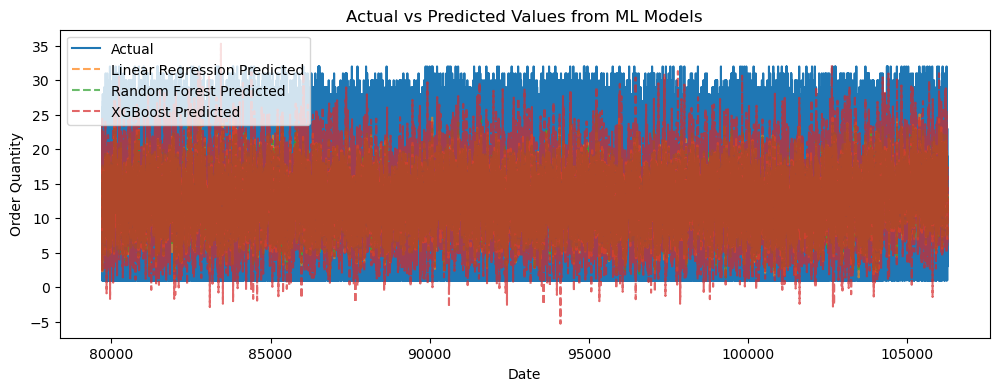

In [213]:
# Plotting visual comparison of the actual values and the predicted values from the three ML models.
plt.figure(figsize=(12, 4))
sns.lineplot(x=y_test.index, y=y_test.values, label='Actual')
sns.lineplot(x=y_test.index, y=y_pred_lr, label='Linear Regression Predicted', linestyle='--', alpha=0.7)
sns.lineplot(x=y_test.index, y=y_pred_rf, label='Random Forest Predicted', linestyle='--', alpha=0.7)
sns.lineplot(x=y_test.index, y=y_pred_xgb, label='XGBoost Predicted', linestyle='--', alpha=0.7)
plt.title('Actual vs Predicted Values from ML Models')
plt.xlabel('Date')
plt.ylabel('Order Quantity')
plt.legend()

In [207]:
# Comparing the performance of all the models in the results dataframe
results_df = pd.DataFrame({
    'Model': ['Prophet(auto)', 'Prophet', 'ARIMA Baseline', 'ARIMA Tuned',
              'Linear Regression', 'Random Forest Regression', 'XGBoost Regression'],
    'MAE': [mae_prophet_auto, mae_prophet, mae_baseline, mae_tuned_arima,
            mae_lr, mae_rf, mae_xgb]
})

results_df

,Model,MAE
0,Prophet(auto),10.765113
1,Prophet,10.765113
2,ARIMA Baseline,8.265485
3,ARIMA Tuned,8.201108
4,Linear Regression,7.365131
5,Random Forest Regression,7.379530
6,XGBoost Regression,7.744087


From the MAE performances, we can see that the linear regression model was the best in the lot. Tuning it can yeild even better results for RF and XGBoost 